# VGG16 - Threshold optimalizacio
- ugyan az a VGG16 halo, csak optimalizalni probalom a thresholdot, hogy kevesebb legyen a false positive

**Importok**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-02-28 17:35:51.014246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772300151.211594      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772300151.264576      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772300151.713680      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772300151.713723      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772300151.713726      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Konfiguracio**

In [2]:
DATASET_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_INITIAL = 6
EPOCHS_FINE = 6
SEED = 42

OUT_ROOT = "kaggle/working"
FIG_DIR = os.path.join(OUT_ROOT, "figures")
MET_DIR = os.path.join(OUT_ROOT, "metrics")
MODEL_DIR = os.path.join(OUT_ROOT, "models")

os.makedirs(FIG_DIR, exist_ok = True)
os.makedirs(MET_DIR, exist_ok = True)
os.makedirs(MODEL_DIR, exist_ok = True)

**Adatgeneratorok - VGG specifikus preprocess input**

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    seed = SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

print("Class indices:", train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


**Class weight**

In [4]:
counts = np.bincount(train_gen.classes)
total = counts.sum()
class_weight = {0: total/(2*counts[0]), 1: total/(2*counts[1])}
print("Train class counts:", counts, "class_weight:", class_weight)

Train class counts: [1341 3875] class_weight: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


**Modell-VGG16**

In [5]:
base = VGG16(
    weights = "imagenet",
    include_top = False,
    input_tensor = Input(shape=(224, 224, 3))
)

#Fagyasztas
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.inputs, outputs=out)

model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

I0000 00:00:1772300179.868600      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Callbackek**

In [6]:
ckpt_path = os.path.join(MODEL_DIR, "vgg16_best.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

**Phase 1 - Training**

In [7]:
history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = EPOCHS_INITIAL,
    callbacks = callbacks,
    class_weight = class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


I0000 00:00:1772300185.891763     143 service.cc:152] XLA service 0x7fee6800e2d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772300185.891800     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772300186.454954     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/163 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.5938 - loss: 1.8377 

I0000 00:00:1772300194.906834     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 775ms/step - accuracy: 0.7169 - loss: 0.9011 - val_accuracy: 0.8750 - val_loss: 0.2606 - learning_rate: 1.0000e-04
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 598ms/step - accuracy: 0.8909 - loss: 0.3376 - val_accuracy: 0.9375 - val_loss: 0.1875 - learning_rate: 1.0000e-04
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 589ms/step - accuracy: 0.9097 - loss: 0.2569 - val_accuracy: 0.9375 - val_loss: 0.1728 - learning_rate: 1.0000e-04
Epoch 4/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.9206 - loss: 0.2082 - val_accuracy: 0.9375 - val_loss: 0.2148 - learning_rate: 1.0000e-04
Epoch 5/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 584ms/step - accuracy: 0.9322 - loss: 0.1669 - val_accuracy: 0.9375 - val_loss: 0.1387 - learning_rate: 1.0000e-04
Epoch 6/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 575ms/step - accuracy: 0.9457 - loss: 0.1484 - val_accuracy: 0.9375 - val_loss: 0.1833 - learning_rate: 1.0000e-04


**Fine-Tuning**
- VGG16-nal erdemes csak a block5-ot engedni

In [8]:
for layer in base.layers:
    if "block5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = EPOCHS_FINE,
    callbacks = callbacks,
    class_weight = class_weight
)

Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 582ms/step - accuracy: 0.9410 - loss: 0.1585 - val_accuracy: 0.8125 - val_loss: 0.2657 - learning_rate: 1.0000e-05
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 580ms/step - accuracy: 0.9652 - loss: 0.0902 - val_accuracy: 1.0000 - val_loss: 0.0287 - learning_rate: 1.0000e-05
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 578ms/step - accuracy: 0.9653 - loss: 0.0872 - val_accuracy: 1.0000 - val_loss: 0.0869 - learning_rate: 1.0000e-05
Epoch 4/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9718 - loss: 0.0682 - val_accuracy: 1.0000 - val_loss: 0.0372 - learning_rate: 1.0000e-05
Epoch 5/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.9786 - loss: 0.0537 - val_accuracy: 1.0000 - val_loss: 0.0169 - learning_rate: 1.0000e-05
Epoch 6/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 615ms/step - accuracy: 0.9788 - loss: 0.0599 - val_accuracy: 1.0000 - val_loss: 0.0088 - learning_rate: 1.0000e-05


**Grafikonok**

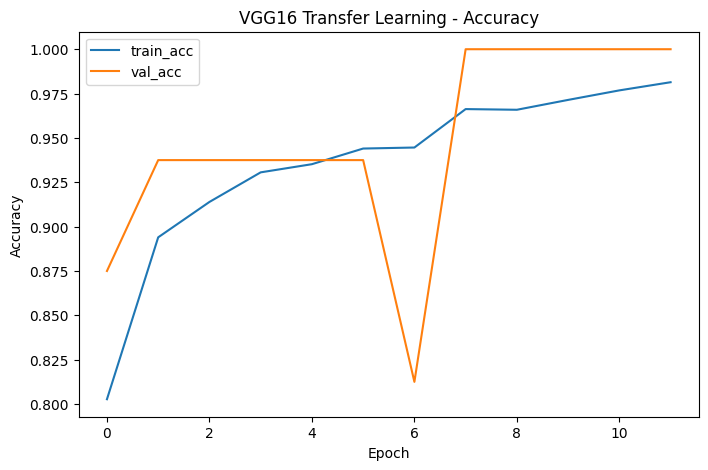

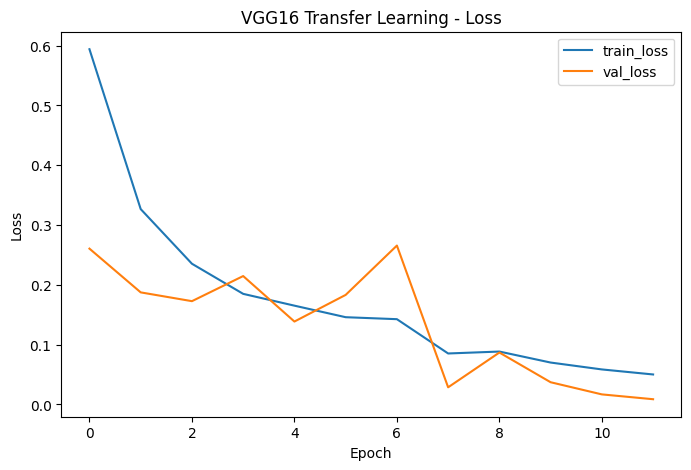

Saved: kaggle/working/figures/mobilenetv2_accuracy.png
Saved: kaggle/working/figures/mobilenetv2_loss.png


In [9]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history.keys():
        merged[k] = h1.history[k] + h2.history[k]
    return merged

hist = merge_histories(history1, history2)

plt.figure(figsize=(8,5))
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Transfer Learning - Accuracy")
plt.legend()
acc_path = os.path.join(FIG_DIR, "mobilenetv2_accuracy.png")
plt.savefig(acc_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Transfer Learning - Loss")
plt.legend()
loss_path = os.path.join(FIG_DIR, "mobilenetv2_loss.png")
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", acc_path)
print("Saved:", loss_path)

**Kiertekeles+JSON mentes**

Threshold | Accuracy | Sensitivity | Specificity
0.30       | 0.9006   | 0.9872     | 0.7564
0.35       | 0.9054   | 0.9846     | 0.7735
0.40       | 0.9071   | 0.9821     | 0.7821
0.45       | 0.9071   | 0.9795     | 0.7863
0.50       | 0.9054   | 0.9769     | 0.7863
0.55       | 0.9103   | 0.9769     | 0.7991
0.60       | 0.9119   | 0.9769     | 0.8034
0.65       | 0.9135   | 0.9744     | 0.8120
0.70       | 0.9151   | 0.9692     | 0.8248
0.75       | 0.9119   | 0.9590     | 0.8333
0.80       | 0.9135   | 0.9462     | 0.8590


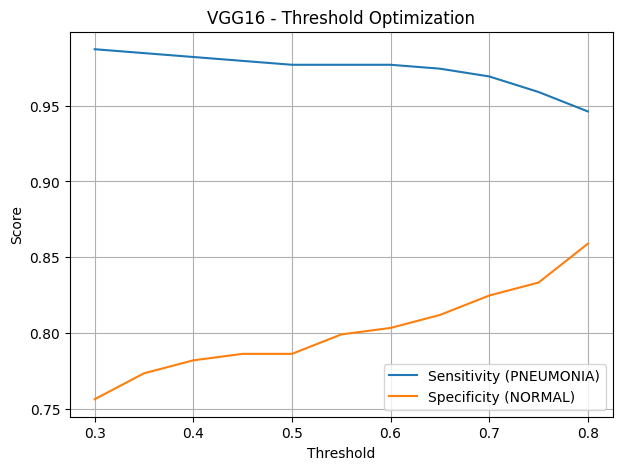

              precision    recall  f1-score   support

      NORMAL       0.95      0.79      0.86       234
   PNEUMONIA       0.88      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.89       624
weighted avg       0.91      0.91      0.90       624



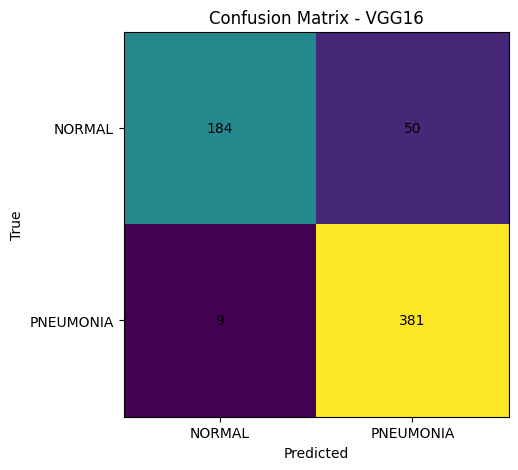

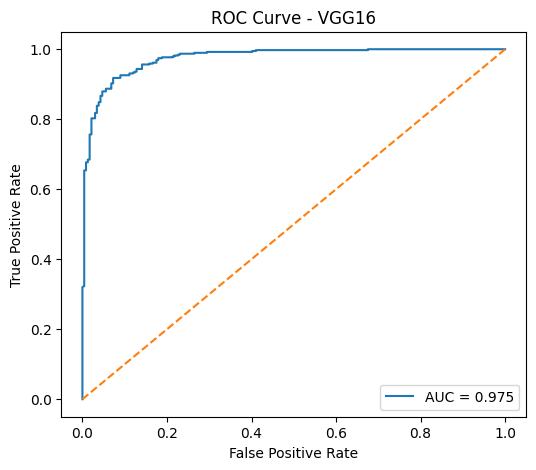

Saved: kaggle/working/figures/vgg16_confusion_matrix.png
Saved: kaggle/working/figures/vgg16_roc.png
Saved: kaggle/working/metrics/vgg16_metrics.json


In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

model.load_weights(ckpt_path)

test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

#THRESHOLD OPTIMALIZACIO
thresholds = np.arange(0.3, 0.81, 0.05)

results = []

for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    cm = confusion_matrix(y_true, y_pred_th)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)  # pneumonia recall
    specificity = tn / (tn + fp)  # normal recall
    acc = accuracy_score(y_true, y_pred_th)
    
    results.append((th, acc, sensitivity, specificity))

print("Threshold | Accuracy | Sensitivity | Specificity")
for r in results:
    print(f"{r[0]:.2f}       | {r[1]:.4f}   | {r[2]:.4f}     | {r[3]:.4f}")

thresholds = [r[0] for r in results]
sens = [r[2] for r in results]
spec = [r[3] for r in results]

plt.figure(figsize=(7,5))
plt.plot(thresholds, sens, label="Sensitivity (PNEUMONIA)")
plt.plot(thresholds, spec, label="Specificity (NORMAL)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("VGG16 - Threshold Optimization")
plt.legend()
plt.grid(True)
plt.show()
    
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

report = classification_report(
    y_true, y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True
)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5,5))
plt.imshow(cm)
plt.title("Confusion Matrix - VGG16")
plt.xticks([0,1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0,1], ["NORMAL", "PNEUMONIA"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
cm_path = os.path.join(FIG_DIR, "vgg16_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16")
plt.legend()
roc_path = os.path.join(FIG_DIR, "vgg16_roc.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()

metrics_out = {
    "model": "VGG16_transfer",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_total": len(hist["loss"]),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}

met_path = os.path.join(MET_DIR, "vgg16_metrics.json")
with open(met_path, "w") as f:
    json.dump(metrics_out, f, indent=2)

print("Saved:", cm_path)
print("Saved:", roc_path)
print("Saved:", met_path)

**Modell save**

In [11]:
final_model_path = os.path.join(MODEL_DIR, "vgg16_final.keras")
model.save(final_model_path)
print("Saved:", final_model_path)

Saved: kaggle/working/models/vgg16_final.keras


**Random predikciok**

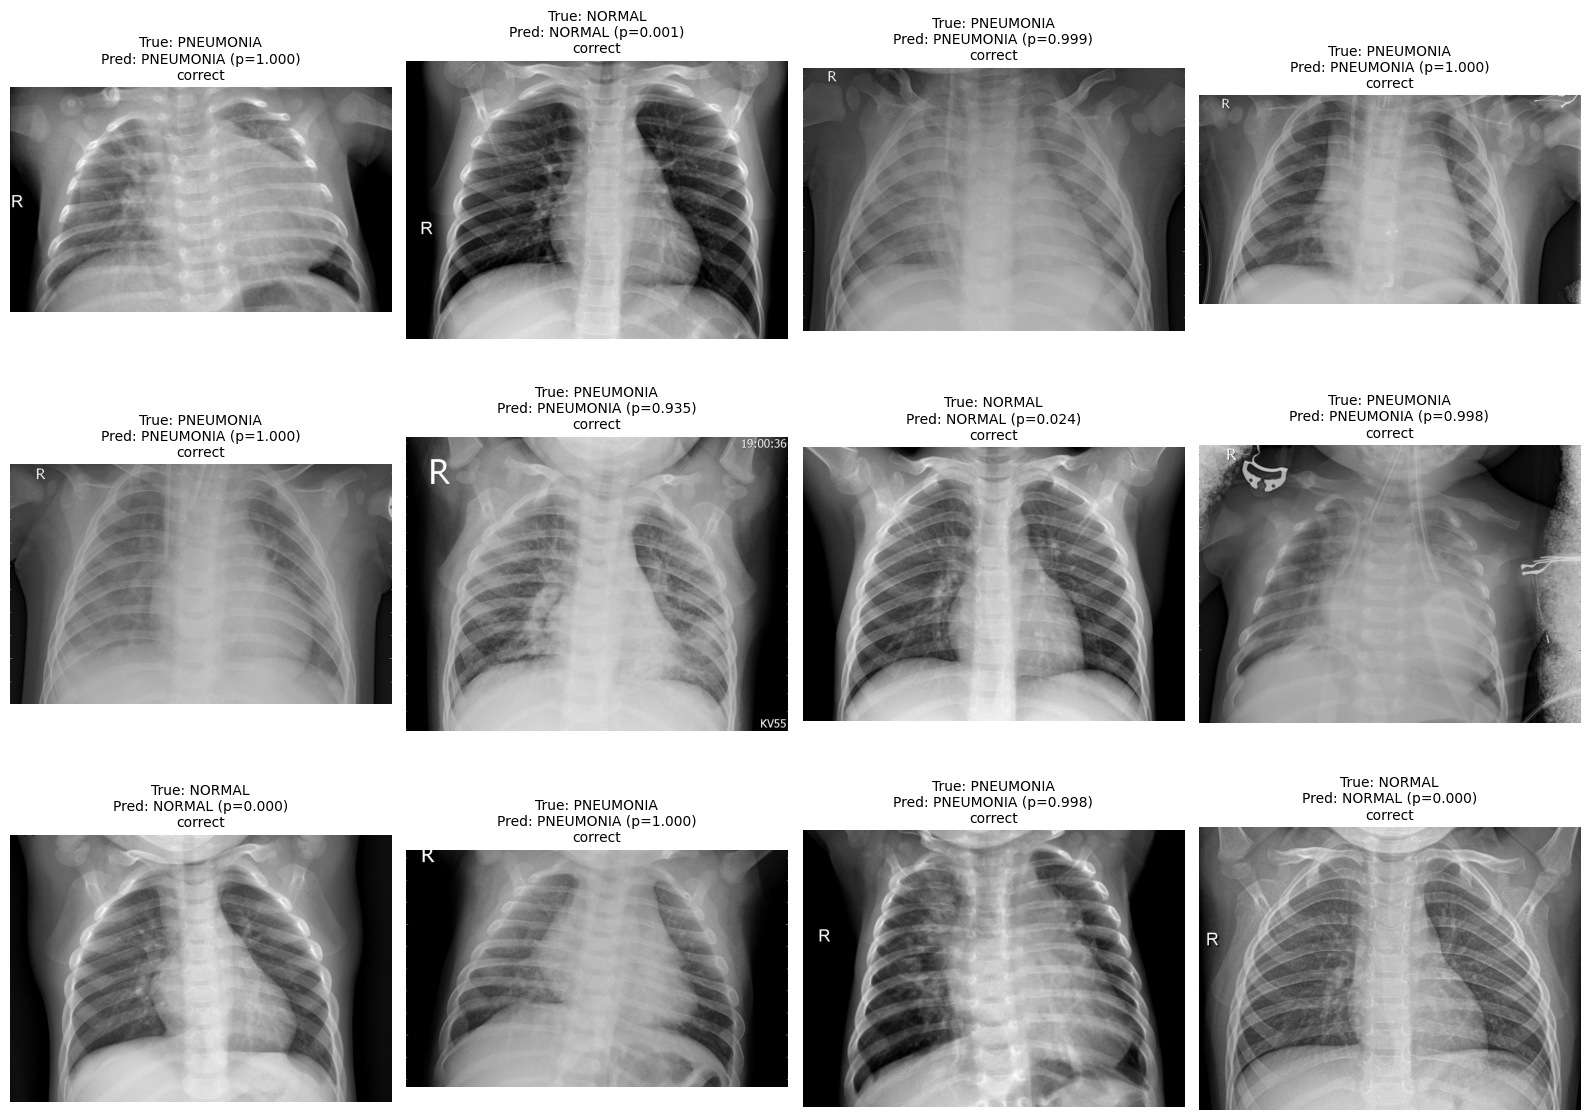

In [12]:
def show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42):
    """
    Random minták a teszt halmazból: kép + true/pred + prob + helyes/hibás jelzés.
    Feltételezi, hogy test_gen shuffle=False.
    """
    rng = np.random.default_rng(seed)

    #predikcio a teljes teszthalmazra(egyszer)
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)

    #indexek kivalasztasa
    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)

    #osztalynevek
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}  # pl. {0:"NORMAL",1:"PNEUMONIA"}
    class_names = [idx_to_class[0], idx_to_class[1]]

    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, idx in enumerate(idxs, start=1):
        #kep betoltese fajlbol
        img_path = test_gen.filepaths[idx]
        img = plt.imread(img_path)

        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob = y_prob[idx]

        correct = (true_label == pred_label)
        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )

        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42)

**Top hibak**

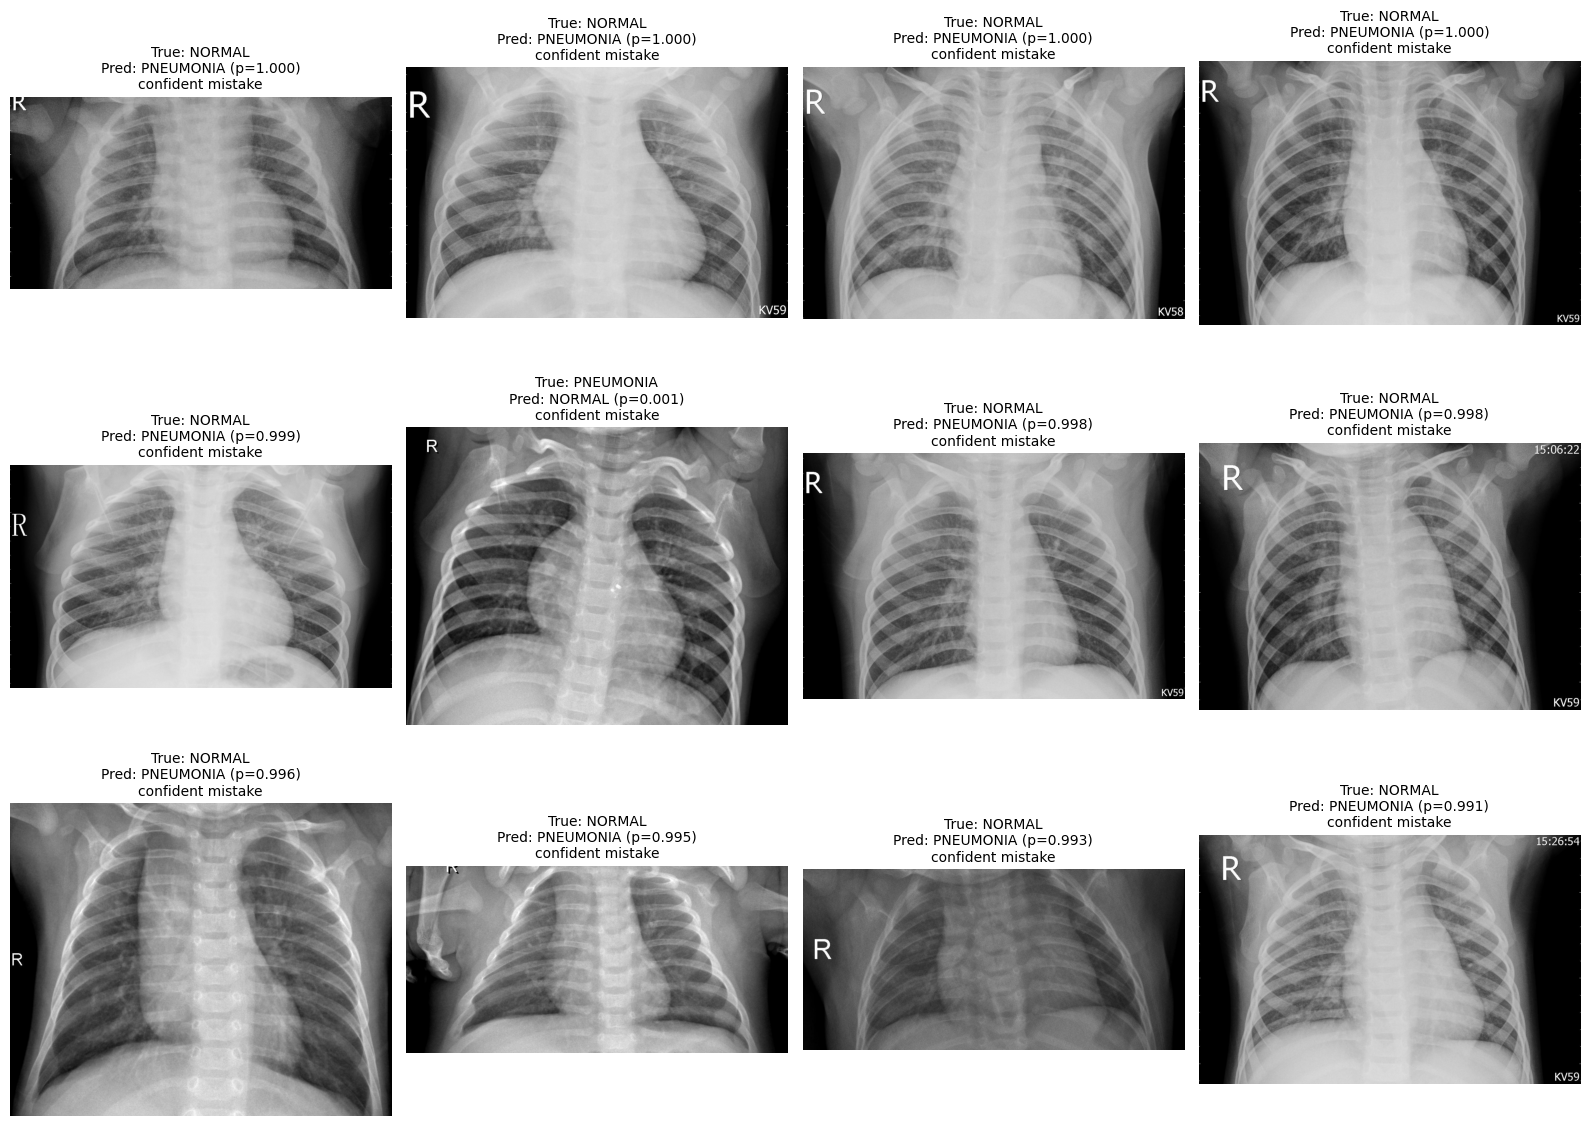

In [13]:
def show_top_mistakes(model, test_gen, k=12, threshold=0.5):
    """
    Megmutatja a k legmagabiztosabb tévedést a teszthalmazból.
    """
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)

    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("Nincs tévesztés a teszthalmazon ezzel a threshold-dal.")
        return

    #"magabiztossag" = mennyire tavol van a 0.5-tol
    confidence = np.abs(y_prob[wrong] - threshold)
    top_wrong = wrong[np.argsort(-confidence)][:min(k, len(wrong))]

    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names = [idx_to_class[0], idx_to_class[1]]

    cols = 4
    rows = int(np.ceil(len(top_wrong) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, idx in enumerate(top_wrong, start=1):
        img_path = test_gen.filepaths[idx]
        img = plt.imread(img_path)

        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob = y_prob[idx]

        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"confident mistake"
        )

        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

show_top_mistakes(model, test_gen, k=12, threshold=0.5)

**Grad-CAM**

In [14]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Nem talalhato Conv2D reteg, Grad-CAM nem alkalmazhato")

last_conv_name = find_last_conv_layer_name(model)
print("Last conv layer:", last_conv_name)

Last conv layer: block5_conv3


In [15]:
def make_gradcam_heatmap(img_batch, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch, training=False)
        score = preds[:, 0]  # sigmoid output

    grads = tape.gradient(score, conv_out)           # (1, Hc, Wc, C)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2)) # (1, C)

    conv_out = conv_out[0]         # (Hc, Wc, C)
    pooled_grads = pooled_grads[0] # (C,)

    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1) # (Hc, Wc)
    heatmap = tf.maximum(heatmap, 0)

    heatmap /= (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


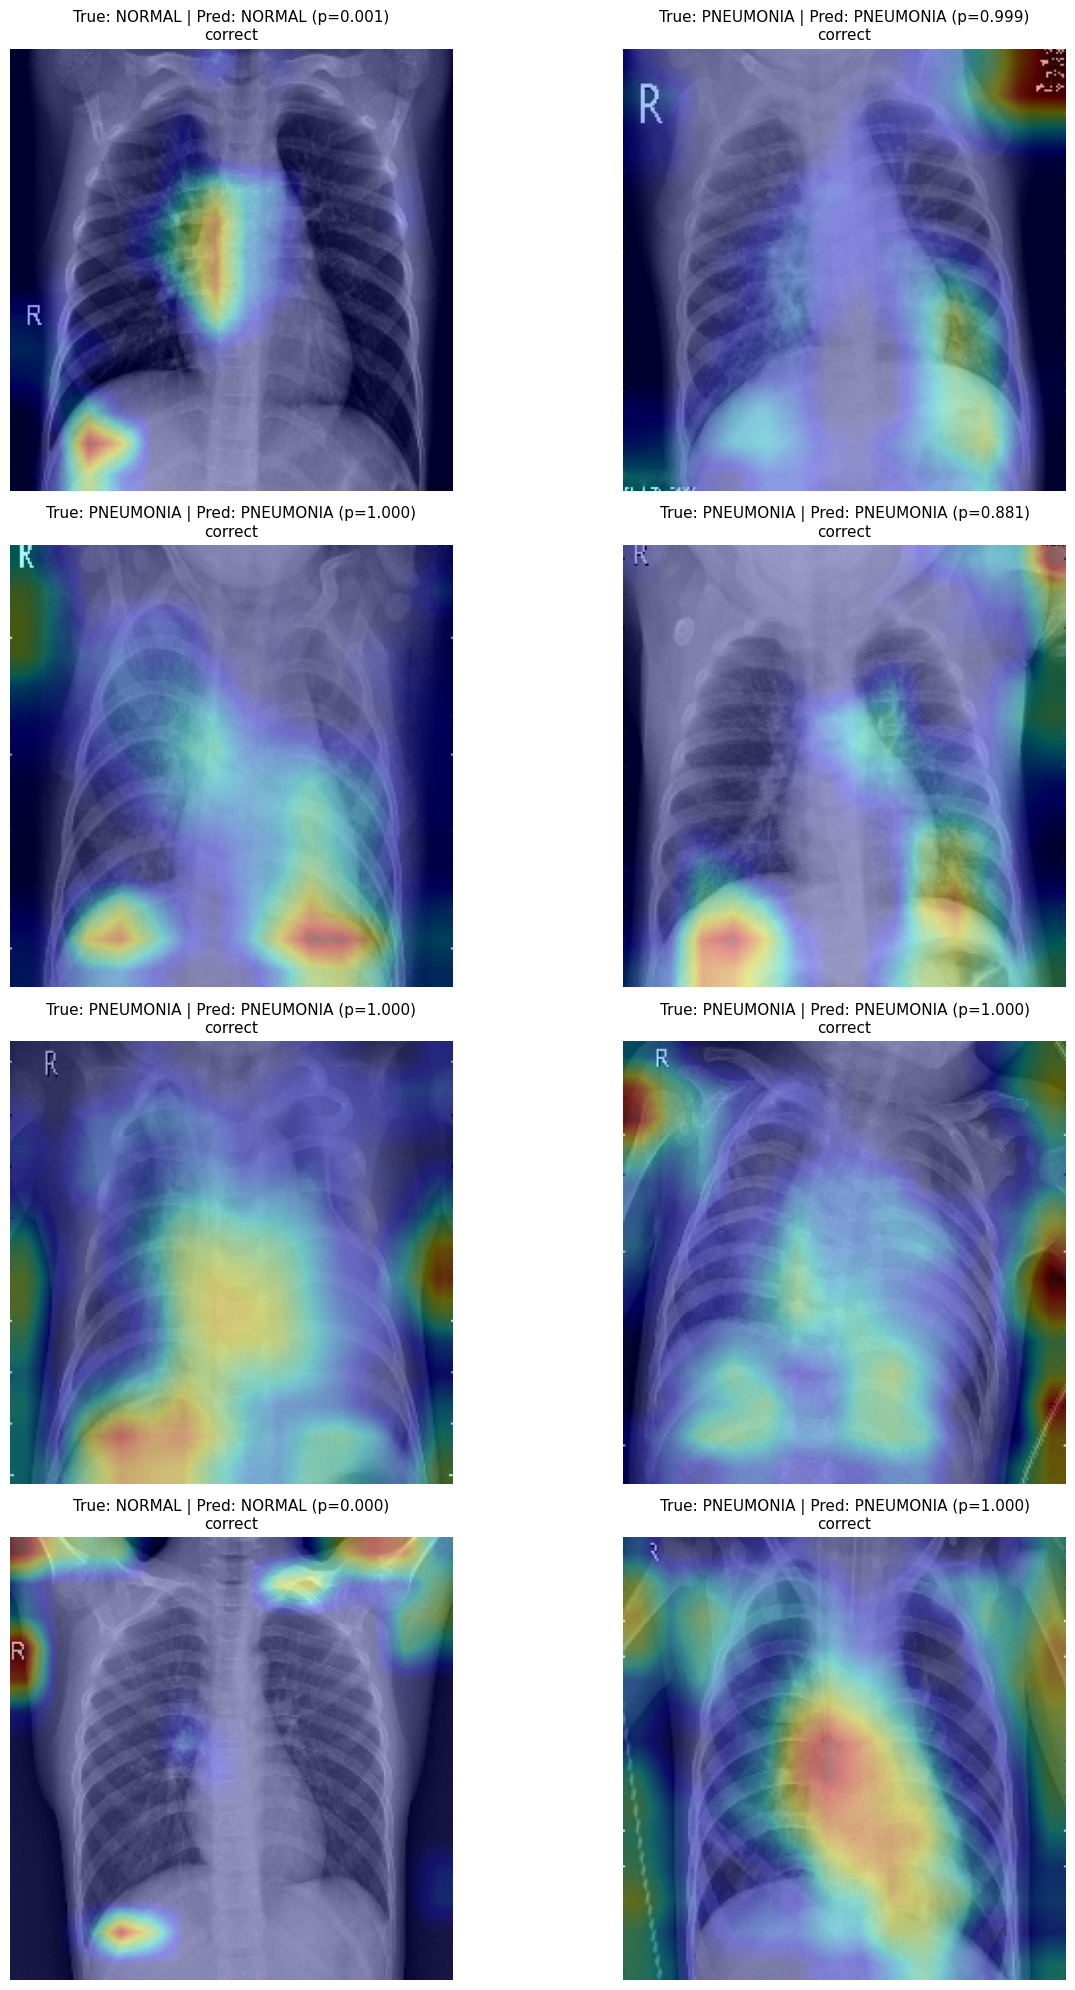

Saved Grad-CAM overlays to: /kaggle/working/figures/gradcam_vgg16


In [16]:
def overlay_heatmap(img_rgb_01, heatmap, alpha=0.35):
    heatmap_tf = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap_tf = tf.image.resize(heatmap_tf, (img_rgb_01.shape[0], img_rgb_01.shape[1]))
    heatmap_resized = heatmap_tf.numpy().squeeze()

    cmap = plt.get_cmap("jet")
    colored = cmap(heatmap_resized)[:, :, :3]

    overlay = (1 - alpha) * img_rgb_01 + alpha * colored
    return np.clip(overlay, 0, 1)

def gradcam_on_test_samples_vgg16(model, test_gen, last_conv_layer_name,
                                         n=8, threshold=0.5, seed=42,
                                         save_dir="/kaggle/working/figures/gradcam_vgg16"):
    rng = np.random.default_rng(seed)

    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)

    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names = [idx_to_class[0], idx_to_class[1]]

    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)

    os.makedirs(save_dir, exist_ok=True)

    cols = 2
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 7, rows * 5))

    for i, idx in enumerate(idxs, start=1):
        img_path = test_gen.filepaths[idx]

        pil_img = tf.keras.utils.load_img(img_path, target_size=test_gen.target_size)
        img_arr = tf.keras.utils.img_to_array(pil_img)  # 0..255 float

        img_rgb_01 = img_arr / 255.0

        img_for_model = preprocess_input(img_arr.copy())
        img_batch = np.expand_dims(img_for_model, axis=0)

        heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)
        overlay_img = overlay_heatmap(img_rgb_01, heatmap, alpha=0.35)

        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob = y_prob[idx]
        correct = (true_label == pred_label)

        title = (
            f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )

        plt.subplot(rows, cols, i)
        plt.imshow(overlay_img)
        plt.axis("off")
        plt.title(title, fontsize=11)

        out_name = f"gradcam_{i:02d}_idx{idx}_true{class_names[true_label]}_pred{class_names[pred_label]}_p{prob:.3f}.png"
        plt.imsave(os.path.join(save_dir, out_name), overlay_img)

    plt.tight_layout()
    plt.show()
    print("Saved Grad-CAM overlays to:", save_dir)

gradcam_on_test_samples_vgg16(
    model=model,
    test_gen=test_gen,
    last_conv_layer_name=last_conv_name,
    n=8,
    threshold=0.5,
    seed=42
)